# 🎯 Notebook 07 — Detección Multi-Alimento: cascada corregida + evaluación sobre FoodSeg103

Este notebook corrige los problemas detectados en el **notebook 06** (primer paso de YOLO, cascada básica) y agrega una evaluación de detección sobre un dataset real de comida con anotaciones densas.

## Qué arregla respecto al notebook 06

El nb06 mostró que la cascada *empeoraba* el baseline: accuracy 86% → 80.5% y, sobre todo, **MAPE calórico 10.3% → 196.3%**. Las causas y sus correcciones:

| Problema en nb06 | Corrección en nb07 |
|---|---|
| Suma kcal de detecciones de **vajilla** (`bowl`, `cup`, `plate`, `fork`...) como si fueran comida | Se separan las clases COCO de **comida** vs **referencia de escala**; la vajilla nunca aporta kcal |
| El **mismo alimento** detectado N veces (cajas solapadas) cuenta N veces | **NMS** entre cajas de comida (IoU > 0.5) elimina los duplicados |
| Cada detección recibe una porción fija de 250 g → la suma explota (2.5 detecciones/img → ~2.5×) | Un **presupuesto único de 250 g por plato** se reparte entre las detecciones **proporcional al área** |
| `mAP@50` no se podía calcular: Food-101 no tiene bounding boxes | Se evalúa sobre **FoodSeg103**, derivando boxes ground-truth desde sus máscaras pixel-wise |

## Dataset elegido: FoodSeg103

`EduardoPacheco/FoodSeg103` (HuggingFace) — 7.120 imágenes de platos reales, 103 categorías de ingredientes, con **máscaras de segmentación pixel-wise**. A diferencia de Food-101 (una foto = un plato), FoodSeg103 tiene **varios ingredientes por imagen**, que es exactamente el escenario que la cascada quiere resolver. De las máscaras derivamos bounding boxes ground-truth para medir `mAP@50`. Además es el benchmark que el ROADMAP define para el Paso 3 (segmentación con SAM), así que el notebook 08 podrá reutilizar el mismo dataset.

> ⚠️ La primera ejecución descarga FoodSeg103 (~2 GB) al caché de HuggingFace. Requiere `pip install datasets` (ver `requirements.txt`).

## ⚙️ Parte 1 — Setup

In [1]:
import sys
sys.path.append('..')

# Forzar tqdm clásico (texto) en vez de widgets de ipywidgets.
# Las barras de progreso de HuggingFace y tqdm.auto siguen apareciendo,
# pero como texto plano — VS Code las renderiza sin tropezar con el
# 'jupyter-ipywidget-renderer'.
import tqdm.std
import tqdm.notebook
import tqdm.auto
tqdm.notebook.tqdm = tqdm.std.tqdm
tqdm.notebook.trange = tqdm.std.trange
tqdm.auto.tqdm = tqdm.std.tqdm
tqdm.auto.trange = tqdm.std.trange

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
import torchvision
from scipy import ndimage
from tqdm import tqdm
from ultralytics import YOLO
from datasets import load_dataset

from src.config import DATA_DIR, WEIGHTS_DIR, DEVICE, SEED, FOOD101_CLASSES
from src.model import load_model
from src.transforms import get_inference_transform
from src.nutrition import get_nutrition

rng = np.random.default_rng(SEED)
print(f'Device: {DEVICE}')

# YOLOv8n preentrenado en COCO (~6 MB, descarga automática)
yolo = YOLO('yolov8n.pt')
print(f'YOLOv8n listo — {len(yolo.names)} clases COCO')

# EfficientNet-B0 fine-tuneado (Food-101)
model_path = WEIGHTS_DIR / 'model_v1.pt'
assert model_path.exists(), 'Correr primero 03_finetuning.ipynb'
classifier = load_model(model_path, backbone='efficientnet_b0', device=DEVICE)
classifier.eval()
transform = get_inference_transform()
print(f'EfficientNet-B0 listo — cargado desde {model_path.name}')


def classify_crop(crop_pil):
    """Clasifica un crop PIL con EfficientNet-B0. Devuelve (clase, confianza, top3)."""
    tensor = transform(crop_pil.convert('RGB')).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(classifier(tensor), dim=1)[0]
    top_prob, top_idx = probs.topk(3)
    return (
        FOOD101_CLASSES[top_idx[0].item()],
        top_prob[0].item(),
        [(FOOD101_CLASSES[top_idx[i].item()], top_prob[i].item()) for i in range(3)],
    )

/Users/nicok/Documents/MIA/Vision por computadora/TP Final/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Device: mps
YOLOv8n listo — 80 clases COCO
EfficientNet-B0 listo — cargado desde model_v1.pt


## 🗂️ Parte 2 — FoodSeg103: descarga y bounding boxes ground-truth

FoodSeg103 trae máscaras pixel-wise (cada píxel tiene un id de ingrediente 0-103, donde 0 = fondo), no bounding boxes. Para evaluar al detector necesitamos boxes, así que los **derivamos de las máscaras**: unimos todo el primer plano (ingrediente > 0) y tomamos una caja por cada componente conexa con área suficiente. Cada caja representa una "región de comida" que el detector debería localizar.

FoodSeg103 (validation): 2135 imágenes
Imagen: (512, 485) | Máscara: (485, 512) | ids de ingrediente presentes: [np.uint8(0), np.uint8(20), np.uint8(56), np.uint8(66), np.uint8(84), np.uint8(96)]


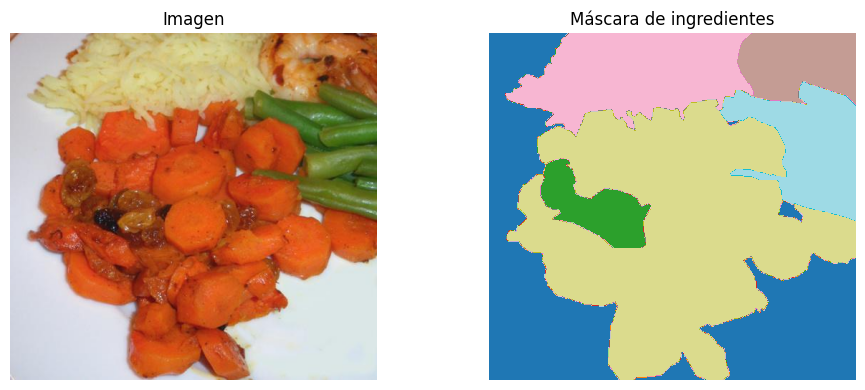

In [2]:
# Descarga / carga desde caché el split de validación (~2.140 imágenes)
foodseg = load_dataset('EduardoPacheco/FoodSeg103', split='validation')
print(f'FoodSeg103 (validation): {len(foodseg)} imágenes')

# Ejemplo: imagen + máscara
sample = foodseg[0]
img0 = sample['image']
mask0 = np.array(sample['label'])
if mask0.ndim == 3:           # por si la máscara viniera como RGB
    mask0 = mask0[..., 0]
print(f'Imagen: {img0.size} | Máscara: {mask0.shape} | '
      f'ids de ingrediente presentes: {sorted(np.unique(mask0))}')

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(img0);                  ax[0].set_title('Imagen');                 ax[0].axis('off')
ax[1].imshow(mask0, cmap='tab20');   ax[1].set_title('Máscara de ingredientes'); ax[1].axis('off')
plt.tight_layout(); plt.show()

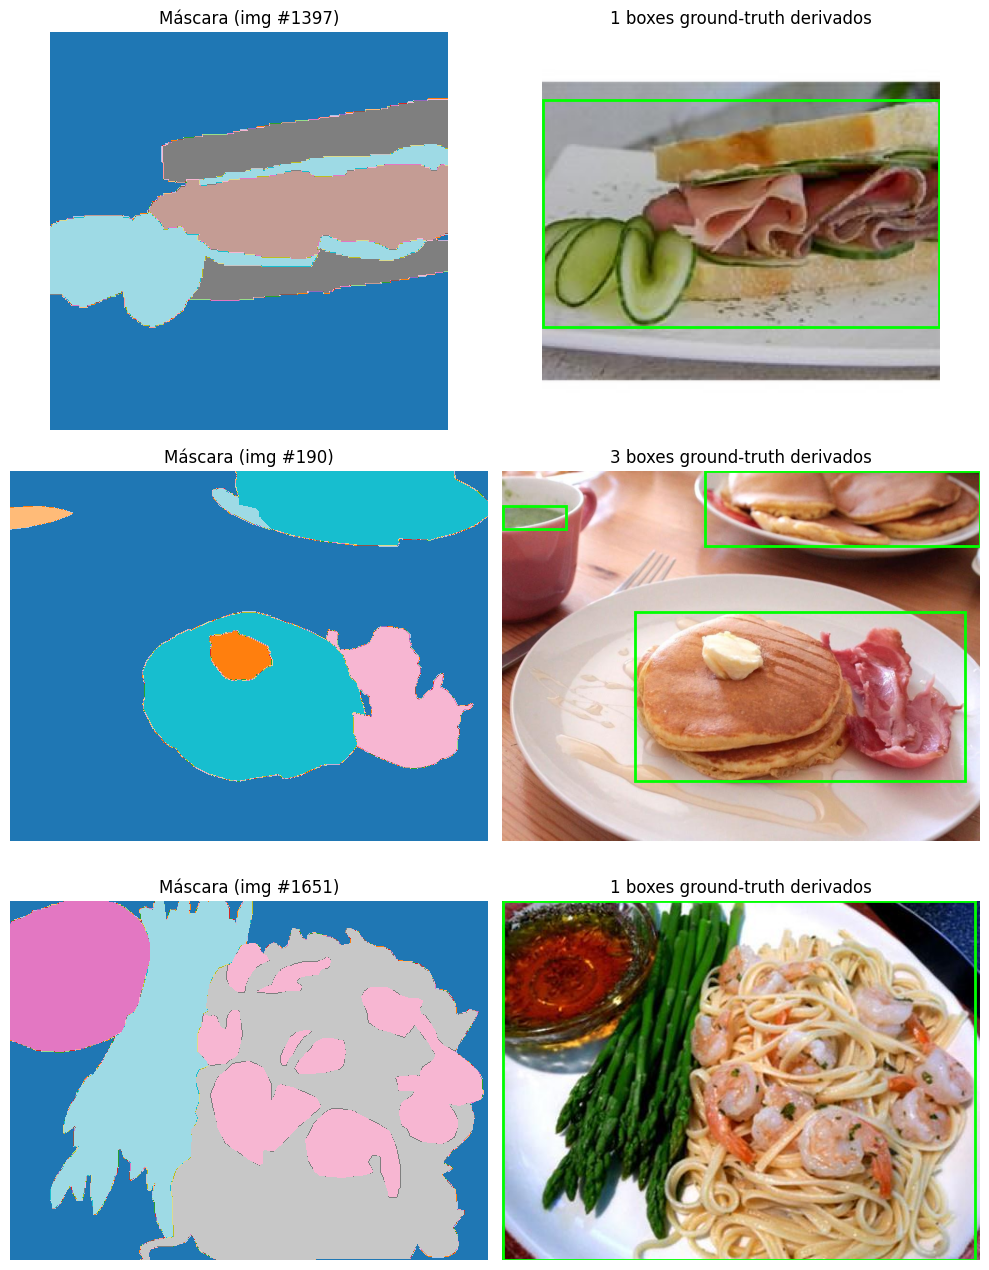

In [3]:
MIN_GT_AREA_FRAC = 0.005   # descarta componentes < 0.5% del área de la imagen


def mask_to_boxes(mask_pil, min_area_frac=MIN_GT_AREA_FRAC):
    """Deriva bounding boxes de comida desde una máscara de FoodSeg103.

    Une todo el primer plano (id > 0) y toma una caja (x1, y1, x2, y2) por
    cada componente conexa con área >= min_area_frac del total.
    """
    mask = np.array(mask_pil)
    if mask.ndim == 3:
        mask = mask[..., 0]
    H, W = mask.shape
    labeled, n = ndimage.label(mask > 0)
    min_area = min_area_frac * H * W
    boxes = []
    for comp_id in range(1, n + 1):
        ys, xs = np.where(labeled == comp_id)
        if len(xs) < min_area:
            continue
        boxes.append((int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())))
    return boxes


def draw_boxes(ax, image, boxes, color='lime', labels=None, style='-'):
    """Dibuja una lista de cajas xyxy sobre un eje."""
    ax.imshow(image)
    for i, (x1, y1, x2, y2) in enumerate(boxes):
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor='none', linestyle=style))
        if labels is not None:
            ax.text(x1, max(0, y1 - 4), labels[i], fontsize=7, color='white',
                    bbox=dict(facecolor=color, alpha=0.8, pad=1.2, edgecolor='none'))
    ax.axis('off')


# Visualización: 3 imágenes con sus boxes ground-truth derivados
idxs_demo = rng.choice(len(foodseg), size=3, replace=False)
fig, axes = plt.subplots(3, 2, figsize=(10, 13))
for row, idx in enumerate(idxs_demo):
    s = foodseg[int(idx)]
    gt_boxes = mask_to_boxes(s['label'])
    axes[row, 0].imshow(np.array(s['label']), cmap='tab20')
    axes[row, 0].set_title(f'Máscara (img #{idx})'); axes[row, 0].axis('off')
    draw_boxes(axes[row, 1], s['image'].convert('RGB'), gt_boxes, color='lime')
    axes[row, 1].set_title(f'{len(gt_boxes)} boxes ground-truth derivados')
plt.tight_layout(); plt.show()

## 🔗 Parte 3 — Pipeline cascada corregido (v2)

`detect_and_classify_v2` separa las detecciones de YOLO en dos grupos:

- **Comida** (`pizza`, `sandwich`, `donut`, `cake`, `apple`, `broccoli`...): se clasifican con EfficientNet-B0 y aportan kcal.
- **Referencia de escala** (`bowl`, `plate`, `cup`, `fork`, `knife`...): se detectan y se muestran, pero **nunca aportan kcal**. En el Paso 4 del ROADMAP estas cajas servirán para estimar la escala real del plato.

Según qué encuentre YOLO, el pipeline opera en uno de tres modos:

| Modo | Cuándo | Porción |
|---|---|---|
| `multi-food` | YOLO detecta ≥ 1 clase de comida | Presupuesto de 250 g repartido entre las detecciones **proporcional al área** |
| `container` | YOLO solo detecta vajilla (la comida está adentro) | El contenedor más grande se clasifica como **1 plato** con 250 g |
| `fallback` | YOLO no detecta nada útil | Imagen completa → 1 plato con 250 g (idéntico al baseline) |

Así el total calórico queda acotado a ~1 porción por plato, en vez de crecer con el número de cajas como pasaba en el nb06.

In [4]:
# Clases COCO que SÍ son comida (aportan kcal)
FOOD_COCO_CLASSES = {
    'pizza', 'donut', 'cake', 'sandwich', 'hot dog',
    'apple', 'banana', 'orange', 'broccoli', 'carrot',
}
# Clases COCO de vajilla / contexto: referencia de escala, NO aportan kcal
SCALE_REF_CLASSES = {
    'bowl', 'cup', 'plate', 'dining table',
    'fork', 'knife', 'spoon', 'wine glass', 'bottle',
}
PLATE_PORTION_G = 250.0   # presupuesto de porción por plato (mismo que el baseline)


def compute_iou(box_a, box_b):
    """IoU entre dos cajas en formato xyxy."""
    ix1, iy1 = max(box_a[0], box_b[0]), max(box_a[1], box_b[1])
    ix2, iy2 = min(box_a[2], box_b[2]), min(box_a[3], box_b[3])
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    area_a = max(0.0, box_a[2] - box_a[0]) * max(0.0, box_a[3] - box_a[1])
    area_b = max(0.0, box_b[2] - box_b[0]) * max(0.0, box_b[3] - box_b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def nms(boxes, scores, iou_thr=0.5):
    """NMS greedy. Devuelve los índices de las cajas a conservar."""
    order = list(np.argsort(scores)[::-1])
    keep = []
    while order:
        i = order.pop(0)
        keep.append(i)
        order = [j for j in order if compute_iou(boxes[i], boxes[j]) < iou_thr]
    return keep


def _crop(image, box, pad=0.05):
    """Recorta una caja xyxy con un padding relativo."""
    W, H = image.size
    x1, y1, x2, y2 = box
    px, py = int((x2 - x1) * pad), int((y2 - y1) * pad)
    return image.crop((max(0, x1 - px), max(0, y1 - py),
                       min(W, x2 + px), min(H, y2 + py)))


def detect_and_classify_v2(image, conf_yolo=0.25, min_box_area=0.02):
    """Pipeline cascada corregido: YOLOv8 -> (comida | escala) -> EfficientNet-B0 -> kcal.

    Returns:
        detections: lista de dicts (box, role, coco_class, food101_class,
                    confidence, portion_g, kcal)
        total_kcal: suma de kcal solo de las detecciones de comida
        mode: 'multi-food' | 'container' | 'fallback'
    """
    if isinstance(image, str):
        image = Image.open(image)
    image = image.convert('RGB')
    W, H = image.size
    img_area = W * H

    results = yolo(image, conf=conf_yolo, verbose=False)[0]
    names = results.names

    food_boxes, food_scores, ref_boxes = [], [], []
    for box, conf, cls_id in zip(results.boxes.xyxy.cpu().numpy(),
                                 results.boxes.conf.cpu().numpy(),
                                 results.boxes.cls.cpu().numpy()):
        x1, y1, x2, y2 = box.astype(int)
        if (x2 - x1) * (y2 - y1) / img_area < min_box_area:
            continue
        cls_name = names[int(cls_id)]
        if cls_name in FOOD_COCO_CLASSES:
            food_boxes.append((x1, y1, x2, y2)); food_scores.append(float(conf))
        elif cls_name in SCALE_REF_CLASSES:
            ref_boxes.append(((x1, y1, x2, y2), cls_name, float(conf)))

    # Dedup de cajas de comida solapadas
    if food_boxes:
        keep = nms(food_boxes, food_scores, iou_thr=0.5)
        food_boxes = [food_boxes[i] for i in keep]
        food_scores = [food_scores[i] for i in keep]

    # Cajas de referencia de escala: siempre se muestran, nunca aportan kcal
    detections = [dict(box=b, role='scale_ref', coco_class=name, food101_class=None,
                       confidence=conf, portion_g=None, kcal=None)
                  for b, name, conf in ref_boxes]

    if food_boxes:
        mode = 'multi-food'
        areas = [(x2 - x1) * (y2 - y1) for (x1, y1, x2, y2) in food_boxes]
        total_area = sum(areas)
        for box, area in zip(food_boxes, areas):
            portion = PLATE_PORTION_G * area / total_area      # reparto por área
            cls, cls_conf, _ = classify_crop(_crop(image, box))
            nut = get_nutrition(cls)
            kcal = nut['calories'] * portion / 100 if nut else None
            detections.append(dict(box=box, role='food', coco_class=None,
                                   food101_class=cls, confidence=cls_conf,
                                   portion_g=portion, kcal=kcal))
    elif ref_boxes:
        mode = 'container'
        # la comida está dentro del contenedor más grande -> se clasifica como 1 plato
        biggest = max(range(len(ref_boxes)),
                      key=lambda i: (ref_boxes[i][0][2] - ref_boxes[i][0][0]) *
                                    (ref_boxes[i][0][3] - ref_boxes[i][0][1]))
        box = ref_boxes[biggest][0]
        cls, cls_conf, _ = classify_crop(_crop(image, box))
        nut = get_nutrition(cls)
        detections[biggest] = dict(box=box, role='food', coco_class=None,
                                   food101_class=cls, confidence=cls_conf,
                                   portion_g=PLATE_PORTION_G,
                                   kcal=nut['calories'] * PLATE_PORTION_G / 100 if nut else None)
    else:
        mode = 'fallback'
        cls, cls_conf, _ = classify_crop(image)
        nut = get_nutrition(cls)
        detections.append(dict(box=(0, 0, W, H), role='food', coco_class=None,
                               food101_class=cls, confidence=cls_conf,
                               portion_g=PLATE_PORTION_G,
                               kcal=nut['calories'] * PLATE_PORTION_G / 100 if nut else None))

    total_kcal = sum(d['kcal'] for d in detections if d['kcal'] is not None)
    return detections, total_kcal, mode


print('Pipeline detect_and_classify_v2 listo')

Pipeline detect_and_classify_v2 listo


## 🖼️ Parte 4 — Evaluación cualitativa sobre FoodSeg103

Para 6 imágenes de FoodSeg103 mostramos tres columnas:
- **(a)** Boxes ground-truth derivados de la máscara
- **(b)** Detecciones crudas de YOLOv8 — comida (naranja) vs referencia de escala (gris, punteado)
- **(c)** Salida del pipeline v2: clase Food-101 + kcal por región, modo y total

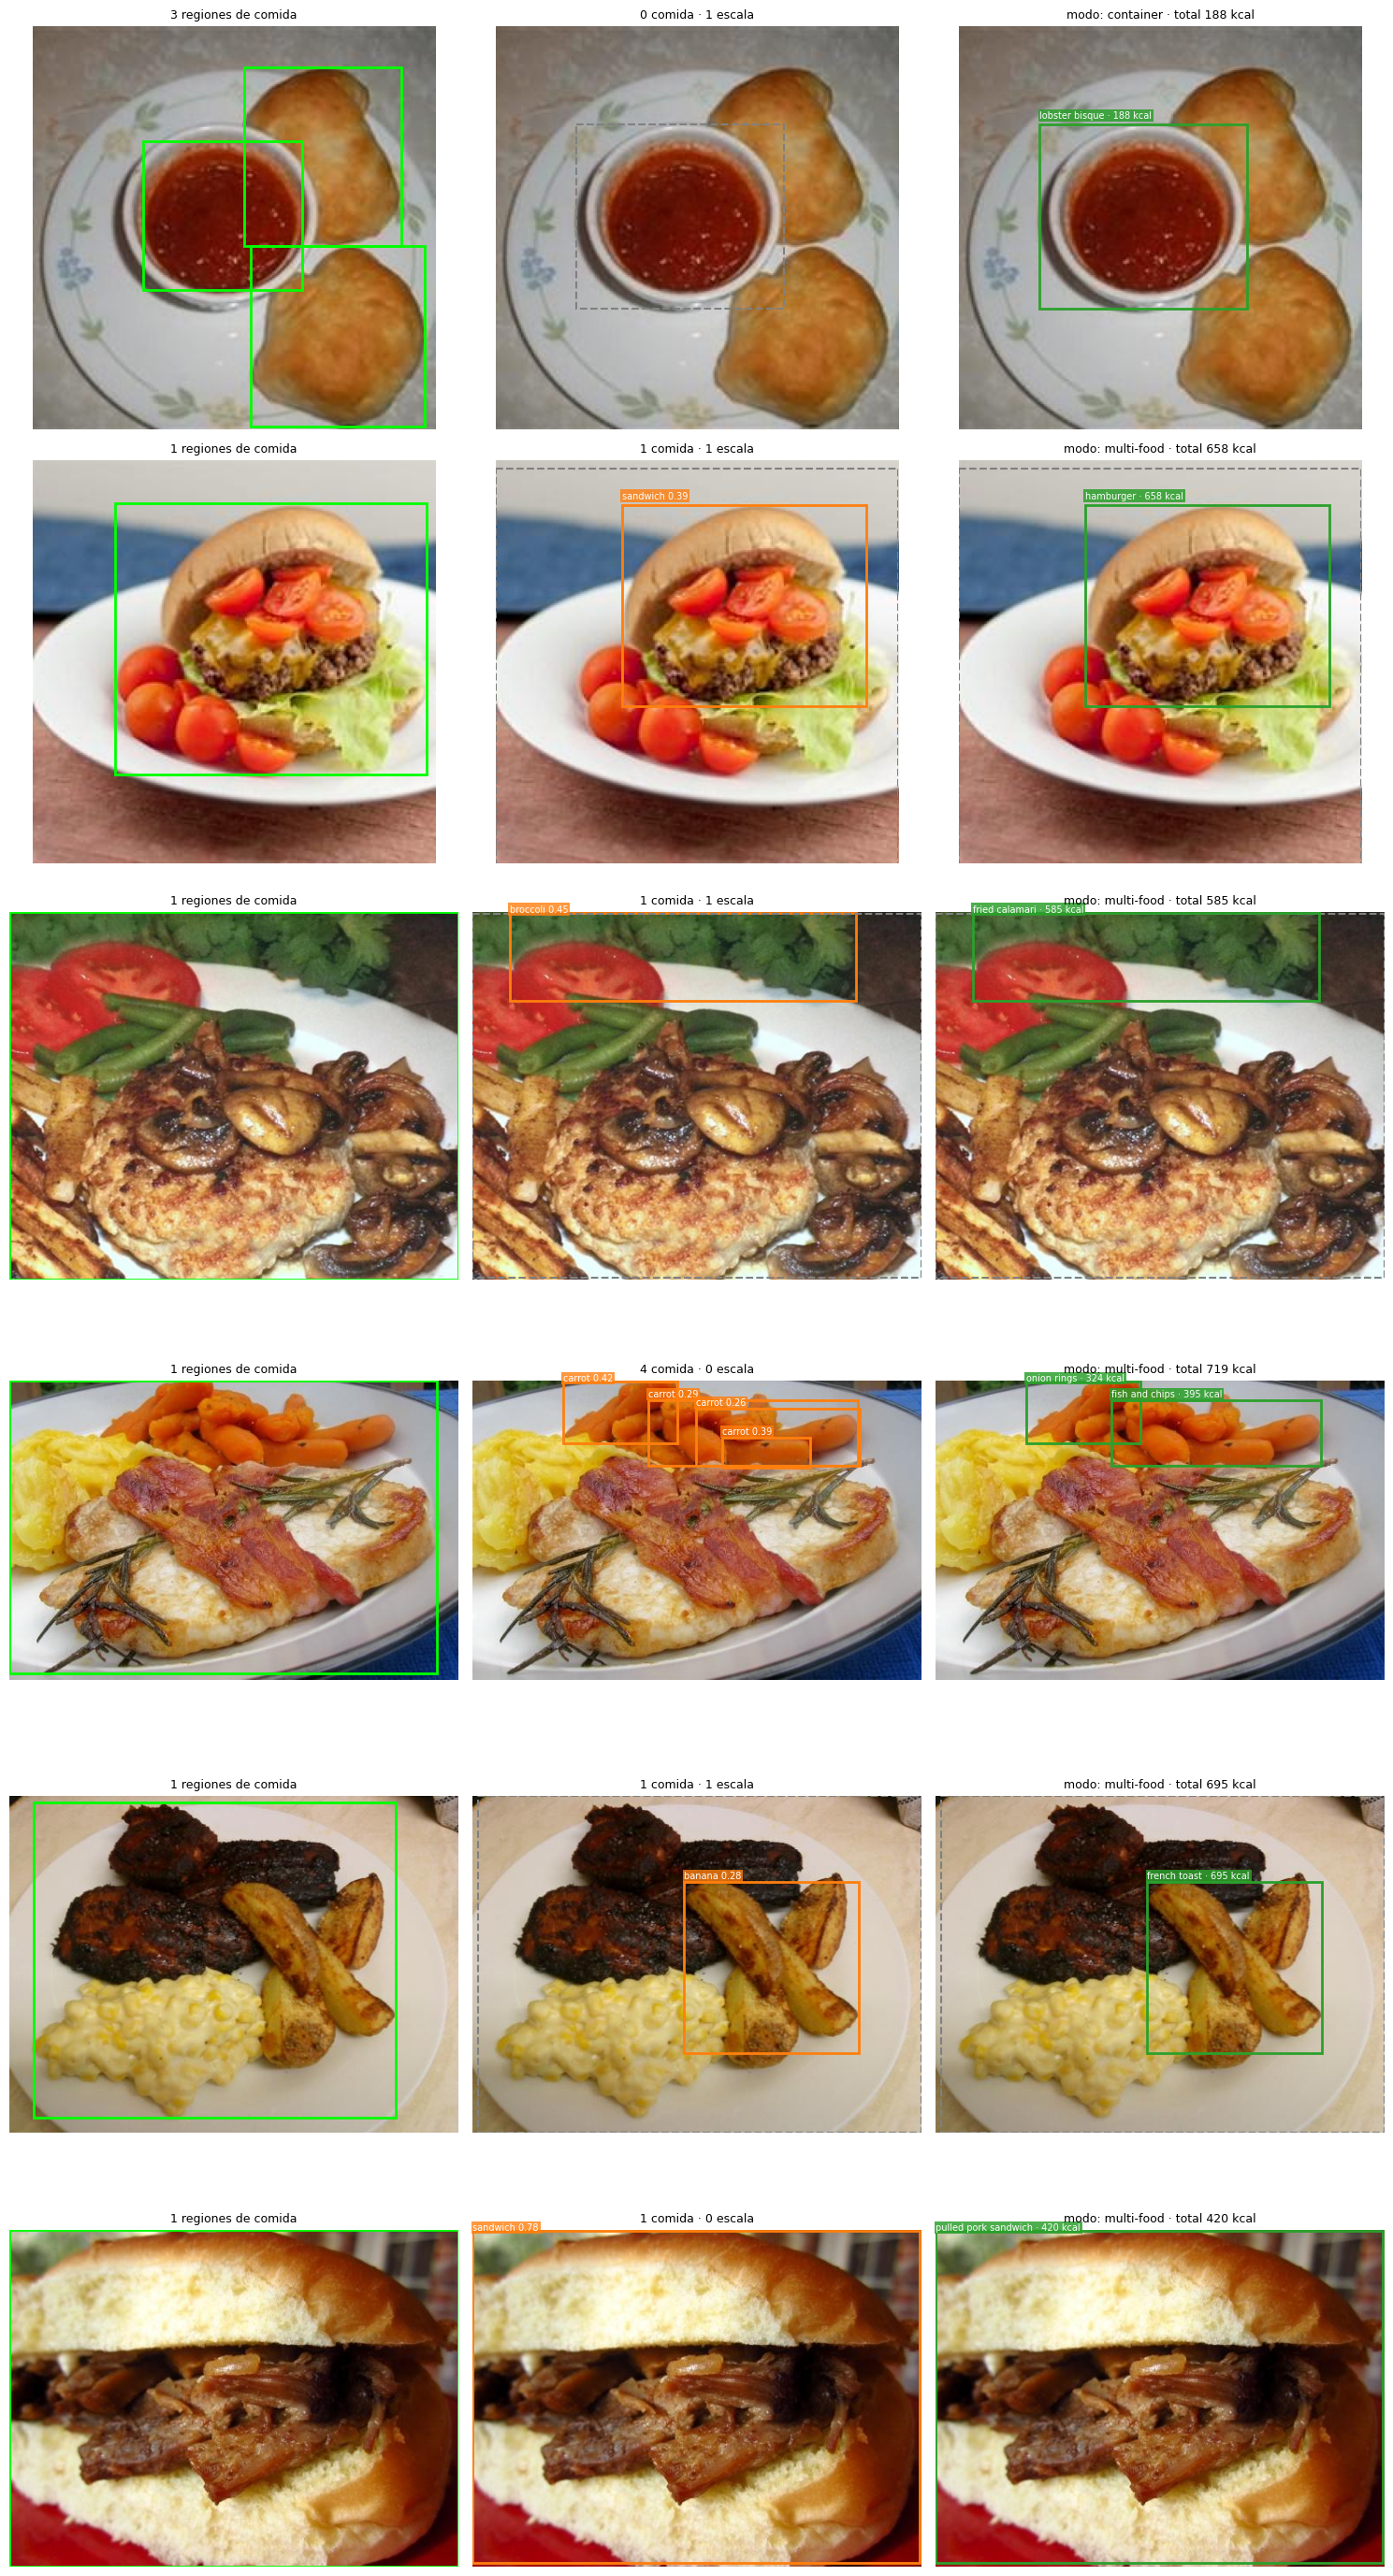

In [5]:
def yolo_raw_boxes(image, conf_yolo=0.25):
    """Detecciones crudas de YOLO separadas en comida / referencia de escala."""
    image = image.convert('RGB')
    results = yolo(image, conf=conf_yolo, verbose=False)[0]
    names = results.names
    food, ref = [], []
    for box, conf, cls_id in zip(results.boxes.xyxy.cpu().numpy(),
                                 results.boxes.conf.cpu().numpy(),
                                 results.boxes.cls.cpu().numpy()):
        b = tuple(box.astype(int))
        name = names[int(cls_id)]
        if name in FOOD_COCO_CLASSES:
            food.append((b, name, float(conf)))
        elif name in SCALE_REF_CLASSES:
            ref.append((b, name, float(conf)))
    return food, ref


idxs_qual = rng.choice(len(foodseg), size=6, replace=False)
fig, axes = plt.subplots(6, 3, figsize=(15, 28))
for col, header in enumerate(['(a) Ground-truth (máscara)',
                              '(b) YOLOv8 crudo',
                              '(c) Pipeline v2']):
    axes[0, col].set_title(header, fontsize=11, fontweight='bold', pad=10)

for row, idx in enumerate(idxs_qual):
    s = foodseg[int(idx)]
    image = s['image'].convert('RGB')

    # (a) ground-truth
    gt_boxes = mask_to_boxes(s['label'])
    draw_boxes(axes[row, 0], image, gt_boxes, color='lime')
    axes[row, 0].set_title(f'{len(gt_boxes)} regiones de comida', fontsize=9)

    # (b) YOLO crudo
    food, ref = yolo_raw_boxes(image)
    axes[row, 1].imshow(image); axes[row, 1].axis('off')
    for b, name, conf in food:
        x1, y1, x2, y2 = b
        axes[row, 1].add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor='tab:orange', facecolor='none'))
        axes[row, 1].text(x1, max(0, y1 - 4), f'{name} {conf:.2f}', fontsize=7,
            color='white', bbox=dict(facecolor='tab:orange', alpha=0.8, pad=1.2, edgecolor='none'))
    for b, name, conf in ref:
        x1, y1, x2, y2 = b
        axes[row, 1].add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
            linewidth=1.5, edgecolor='gray', facecolor='none', linestyle='--'))
    axes[row, 1].set_title(f'{len(food)} comida · {len(ref)} escala', fontsize=9)

    # (c) pipeline v2
    dets, total_kcal, mode = detect_and_classify_v2(image)
    axes[row, 2].imshow(image); axes[row, 2].axis('off')
    for d in dets:
        x1, y1, x2, y2 = d['box']
        if d['role'] == 'scale_ref':
            axes[row, 2].add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                linewidth=1.5, edgecolor='gray', facecolor='none', linestyle='--'))
        else:
            axes[row, 2].add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor='tab:green', facecolor='none'))
            axes[row, 2].text(x1, max(0, y1 - 4),
                f"{d['food101_class'].replace('_', ' ')} · {d['kcal']:.0f} kcal",
                fontsize=7, color='white',
                bbox=dict(facecolor='tab:green', alpha=0.85, pad=1.2, edgecolor='none'))
    axes[row, 2].set_title(f'modo: {mode} · total {total_kcal:.0f} kcal', fontsize=9)

plt.tight_layout()
plt.savefig('detection_qualitative_v2.png', dpi=110, bbox_inches='tight')
plt.show()

## 📊 Parte 5 — `mAP@50` real del detector sobre FoodSeg103

Ahora que tenemos boxes ground-truth podemos medir lo que el nb06 no podía: **qué tan bien YOLOv8-COCO localiza la comida**. Es una evaluación *class-agnostic* — no nos importa si YOLO dice "bowl" o "pizza", solo si pone una caja donde hay comida — porque para el Paso 3 (SAM) lo único que necesitamos son cajas razonables para usar como prompts.

Usamos el protocolo estándar de detección: emparejado por score descendente, IoU ≥ 0.50 para TP, curva Precision-Recall y AP por interpolación all-points (VOC).

Evaluando detección sobre FoodSeg103: 100%|██████████| 150/150 [00:04<00:00, 33.22it/s]


=== Detección YOLOv8-COCO sobre 150 imágenes de FoodSeg103 ===
Ground-truth: 230 regiones de comida   Predicciones: 486
AP@50:     0.1164
Precision: 0.2222
Recall:    0.4696
F1:        0.3017


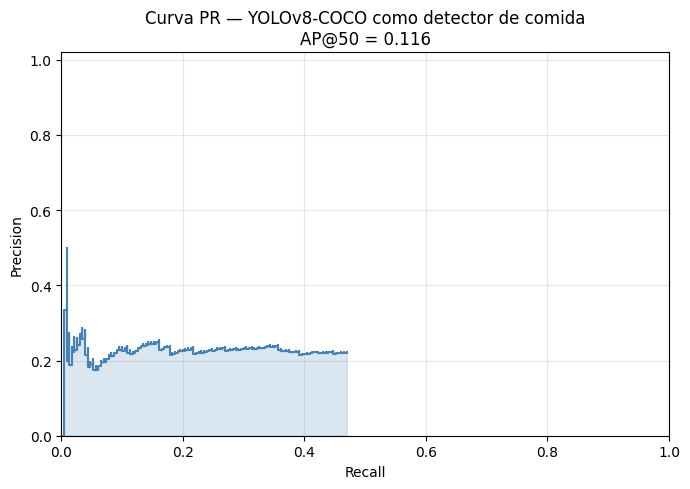

In [6]:
def evaluate_detection(preds_per_img, gts_per_img, iou_thr=0.5):
    """mAP@50 class-agnostic (protocolo VOC all-points).

    preds_per_img: lista por imagen de (box_xyxy, score)
    gts_per_img:   lista por imagen de box_xyxy
    """
    flat = [(score, i, box)
            for i, preds in enumerate(preds_per_img) for box, score in preds]
    flat.sort(key=lambda t: t[0], reverse=True)
    n_gt = sum(len(g) for g in gts_per_img)

    matched = {i: set() for i in range(len(gts_per_img))}
    tp = np.zeros(len(flat)); fp = np.zeros(len(flat))
    for k, (score, img_idx, box) in enumerate(flat):
        best_iou, best_j = 0.0, -1
        for j, gt in enumerate(gts_per_img[img_idx]):
            if j in matched[img_idx]:
                continue
            iou = compute_iou(box, gt)
            if iou > best_iou:
                best_iou, best_j = iou, j
        if best_iou >= iou_thr:
            tp[k] = 1; matched[img_idx].add(best_j)
        else:
            fp[k] = 1

    acc_tp, acc_fp = np.cumsum(tp), np.cumsum(fp)
    recall = acc_tp / max(n_gt, 1)
    precision = acc_tp / np.maximum(acc_tp + acc_fp, 1e-9)
    p_interp = np.maximum.accumulate(precision[::-1])[::-1] if len(precision) else precision
    ap = float(np.sum(np.diff(np.concatenate([[0.0], recall])) * p_interp)) if len(recall) else 0.0

    total_tp = float(acc_tp[-1]) if len(acc_tp) else 0.0
    P = total_tp / max(len(flat), 1)
    R = total_tp / max(n_gt, 1)
    F1 = 2 * P * R / max(P + R, 1e-9)
    return dict(precision=precision, recall=recall, ap=ap,
                P=P, R=R, F1=F1, n_gt=n_gt, n_pred=len(flat))


N_DET_EVAL = 150   # imágenes de validación de FoodSeg103
det_indices = rng.choice(len(foodseg), size=N_DET_EVAL, replace=False)

preds_per_img, gts_per_img = [], []
for idx in tqdm(det_indices, desc='Evaluando detección sobre FoodSeg103'):
    s = foodseg[int(idx)]
    food, ref = yolo_raw_boxes(s['image'])
    # predicciones = todas las cajas relevantes para el pipeline (comida + escala)
    preds_per_img.append([(b, conf) for b, _, conf in food + ref])
    gts_per_img.append(mask_to_boxes(s['label']))

det = evaluate_detection(preds_per_img, gts_per_img, iou_thr=0.5)

print(f'=== Detección YOLOv8-COCO sobre {N_DET_EVAL} imágenes de FoodSeg103 ===')
print(f'Ground-truth: {det["n_gt"]} regiones de comida   Predicciones: {det["n_pred"]}')
print(f'AP@50:     {det["ap"]:.4f}')
print(f'Precision: {det["P"]:.4f}')
print(f'Recall:    {det["R"]:.4f}')
print(f'F1:        {det["F1"]:.4f}')

fig, ax = plt.subplots(figsize=(7, 5))
ax.step(det['recall'], det['precision'], where='post', color='steelblue')
ax.fill_between(det['recall'], det['precision'], step='post', alpha=0.2, color='steelblue')
ax.set(xlabel='Recall', ylabel='Precision', xlim=(0, 1), ylim=(0, 1.02),
       title=f'Curva PR — YOLOv8-COCO como detector de comida\nAP@50 = {det["ap"]:.3f}')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('detection_map_foodseg103.png', dpi=120, bbox_inches='tight')
plt.show()

## 🔢 Parte 6 — Re-evaluación calórica sobre Food-101: ¿se corrigió el MAPE 196%?

FoodSeg103 no tiene ground-truth de calorías, así que para medir el error calórico volvemos a Food-101 con **exactamente el mismo protocolo del nb06** (porción fija de 250 g, GT sintético = lookup × 2.5). Comparamos tres pipelines sobre la misma muestra:

1. **Baseline** — imagen completa → EfficientNet (lo que ya reportaba el nb05)
2. **Cascada v1** — la del nb06: suma kcal de todas las cajas (comida + vajilla), 250 g cada una
3. **Cascada v2** — la de este notebook: vajilla excluida, NMS, presupuesto de 250 g repartido por área

El objetivo es aislar el efecto de las correcciones de agregación.

Re-evaluación calórica (Food-101): 100%|██████████| 200/200 [00:20<00:00,  9.66it/s]


=== MAPE calórico sobre 200 imágenes de Food-101 (porción 250 g) ===
  Baseline (imagen completa):       11.5%
  Cascada v1 (nb06, suma ingenua):  238.5%
  Cascada v2 (nb07, corregida):      32.3%


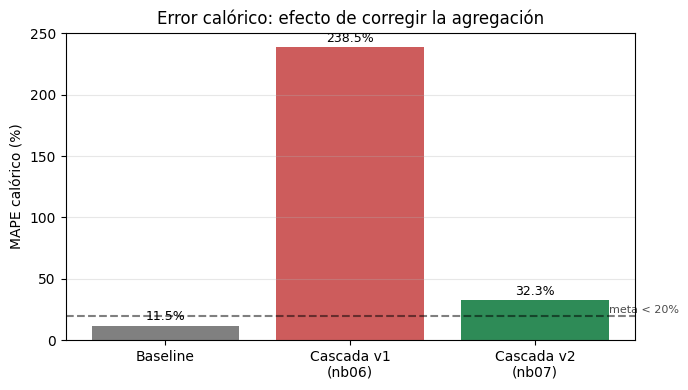

In [7]:
food101_test = torchvision.datasets.Food101(str(DATA_DIR), split='test',
                                            transform=None, download=False)

# Clases COCO usadas por la cascada v1 del nb06 (comida + vajilla mezcladas)
NAIVE_CLASSES = FOOD_COCO_CLASSES | SCALE_REF_CLASSES


def baseline_kcal(image):
    """Baseline: imagen completa -> 1 plato de 250 g."""
    cls, _, _ = classify_crop(image)
    nut = get_nutrition(cls)
    return nut['calories'] * PLATE_PORTION_G / 100 if nut else None


def naive_cascade_kcal(image, conf_yolo=0.25, min_box_area=0.02):
    """Reproduce la cascada del nb06: cada caja relevante suma 250 g."""
    image = image.convert('RGB')
    W, H = image.size
    img_area = W * H
    results = yolo(image, conf=conf_yolo, verbose=False)[0]
    names = results.names
    total, found = 0.0, False
    for box, cls_id in zip(results.boxes.xyxy.cpu().numpy(),
                           results.boxes.cls.cpu().numpy()):
        x1, y1, x2, y2 = box.astype(int)
        if (x2 - x1) * (y2 - y1) / img_area < min_box_area:
            continue
        if names[int(cls_id)] not in NAIVE_CLASSES:
            continue
        found = True
        cls, _, _ = classify_crop(_crop(image, (x1, y1, x2, y2)))
        nut = get_nutrition(cls)
        if nut:
            total += nut['calories'] * PLATE_PORTION_G / 100
    return total if found else baseline_kcal(image)


N_KCAL_EVAL = 200
kcal_indices = rng.choice(len(food101_test), size=N_KCAL_EVAL, replace=False)

rows = []
for idx in tqdm(kcal_indices, desc='Re-evaluación calórica (Food-101)'):
    image, label = food101_test[int(idx)]
    true_nut = get_nutrition(FOOD101_CLASSES[label])
    if true_nut is None:
        continue
    _, v2_kcal, _ = detect_and_classify_v2(image)
    rows.append(dict(
        true_kcal=true_nut['calories'] * PLATE_PORTION_G / 100,
        bl_kcal=baseline_kcal(image),
        v1_kcal=naive_cascade_kcal(image),
        v2_kcal=v2_kcal,
    ))

dfk = pd.DataFrame(rows)


def mape(col):
    return (abs(dfk[col] - dfk['true_kcal']) / dfk['true_kcal']).mean() * 100


print(f'\n=== MAPE calórico sobre {len(dfk)} imágenes de Food-101 (porción 250 g) ===')
print(f'  Baseline (imagen completa):     {mape("bl_kcal"):6.1f}%')
print(f'  Cascada v1 (nb06, suma ingenua): {mape("v1_kcal"):6.1f}%')
print(f'  Cascada v2 (nb07, corregida):    {mape("v2_kcal"):6.1f}%')

fig, ax = plt.subplots(figsize=(7, 4))
labels = ['Baseline', 'Cascada v1\n(nb06)', 'Cascada v2\n(nb07)']
values = [mape('bl_kcal'), mape('v1_kcal'), mape('v2_kcal')]
bars = ax.bar(labels, values, color=['gray', 'indianred', 'seagreen'])
ax.set(ylabel='MAPE calórico (%)', title='Error calórico: efecto de corregir la agregación')
ax.axhline(20, color='k', linestyle='--', alpha=0.5)
ax.text(2.4, 22, 'meta < 20%', fontsize=8, alpha=0.7)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + max(values) * 0.02,
            f'{v:.1f}%', ha='center', fontsize=9)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('calorie_mape_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 📋 Parte 7 — Resumen para el informe

In [8]:
print('=' * 68)
print('RESUMEN — Notebook 07: cascada corregida + evaluación FoodSeg103')
print('=' * 68)
print()
print('Detección (YOLOv8-COCO sobre FoodSeg103, class-agnostic, IoU>=0.50):')
print(f'  AP@50: {det["ap"]:.3f}   Precision: {det["P"]:.3f}   '
      f'Recall: {det["R"]:.3f}   F1: {det["F1"]:.3f}')
print()
print('Error calórico MAPE (Food-101, porción 250 g):')
print(f'  Baseline:    {mape("bl_kcal"):6.1f}%')
print(f'  Cascada v1:  {mape("v1_kcal"):6.1f}%   (nb06 — suma ingenua)')
print(f'  Cascada v2:  {mape("v2_kcal"):6.1f}%   (nb07 — corregida)')
print()
print('Correcciones aplicadas respecto al nb06:')
print('  1. La vajilla (bowl/plate/fork/...) es referencia de escala, no comida.')
print('  2. NMS entre cajas de comida elimina detecciones duplicadas.')
print('  3. Presupuesto de 250 g por plato repartido por área (no 250 g por caja).')
print()
print('Próximo paso (ROADMAP Paso 3): notebook 08 — segmentación con SAM,')
print('usando estos bounding boxes como prompts y FoodSeg103 para medir mIoU/Dice.')
print('=' * 68)

RESUMEN — Notebook 07: cascada corregida + evaluación FoodSeg103

Detección (YOLOv8-COCO sobre FoodSeg103, class-agnostic, IoU>=0.50):
  AP@50: 0.116   Precision: 0.222   Recall: 0.470   F1: 0.302

Error calórico MAPE (Food-101, porción 250 g):
  Baseline:      11.5%
  Cascada v1:   238.5%   (nb06 — suma ingenua)
  Cascada v2:    32.3%   (nb07 — corregida)

Correcciones aplicadas respecto al nb06:
  1. La vajilla (bowl/plate/fork/...) es referencia de escala, no comida.
  2. NMS entre cajas de comida elimina detecciones duplicadas.
  3. Presupuesto de 250 g por plato repartido por área (no 250 g por caja).

Próximo paso (ROADMAP Paso 3): notebook 08 — segmentación con SAM,
usando estos bounding boxes como prompts y FoodSeg103 para medir mIoU/Dice.
